# 06 - Borough Spatial Maps

Four maps for a chosen borough, driven by the parameters cell below:
1. **Graph map** — comment and application locations connected by edges.
2. **Topic map** — comment locations coloured by their primary topic.
3. **Highlight topic map** — chosen topic highlighted, all others faded.
4. **Applications map** — only applications with ≥1 highlighted-topic comment.

In [9]:
import sys
sys.path.append("../functions")

import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import geopandas as gpd

from config import (
    DATA_DIR, FIGURES_DIR, PLD_FILE, LONDON_LAD_FILE,
    COMMENTS_CSV, COMMENTS_TOPICS_CSV, TOPIC_NAMES_CSV,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [10]:
# ── User parameters — edit these to change the analysis ─────────────────────
BOROUGH         = "Newham"  # any council/LAD name present in the dataset
TOPIC_ID        = 10        # topic number to highlight in Maps 3 & 4
HIGHLIGHT_COLOR = None      # hex string to override the topic colour, or None to use its own colour
DARK_MODE       = True      # True = black background, False = white background

# ── Derived style (no need to edit below) ────────────────────────────────────
if DARK_MODE:
    STYLE = dict(
        bg             = "black",
        borough_fill   = "#0d0d1a",
        highlight_fill = "#111122",
        borough_edge   = "white",
        text_color     = "white",
        leg_bg         = "#1a1a2e",
        leg_edge       = "white",
        ghost_color    = "white",
        ghost_alpha    = 0.10,
    )
else:
    STYLE = dict(
        bg             = "white",
        borough_fill   = "#f0f0f0",
        highlight_fill = "#e0e0e0",
        borough_edge   = "#888888",
        text_color     = "black",
        leg_bg         = "white",
        leg_edge       = "#cccccc",
        ghost_color    = "#999999",
        ghost_alpha    = 0.30,
    )

## Load data (local only — no DB connection needed)

In [11]:
comments    = pd.read_csv(COMMENTS_CSV)
pld         = pd.read_parquet(PLD_FILE)
topic_names = pd.read_csv(TOPIC_NAMES_CSV)

topic_color_map = topic_names.set_index("Topic")["color"].to_dict()
topic_group_map = topic_names.set_index("Topic")["topic_group"].to_dict()

# Resolve highlight colour after topic_names is loaded
_highlight = HIGHLIGHT_COLOR or topic_color_map.get(TOPIC_ID, "#DDEA2C")
TOPIC_LABEL = topic_group_map.get(TOPIC_ID, f"topic {TOPIC_ID}")
_slug = BOROUGH.lower().replace(" ", "_")

lad              = gpd.read_file(LONDON_LAD_FILE)
borough_boundary = lad[lad["LAD24NM"] == BOROUGH]

print(f"Borough: {BOROUGH}  |  Highlight topic: {TOPIC_ID} ({TOPIC_LABEL})")
print(f"comments: {len(comments):,}  |  pld: {len(pld):,}")
print(f"Borough boundary loaded: {len(borough_boundary)} polygon(s)")

Borough: Newham  |  Highlight topic: 10 (wrong housing type)
comments: 30,393  |  pld: 28,804
Borough boundary loaded: 1 polygon(s)


## Process — filter to borough, extract centroids, join topics

In [12]:
# --- Filter to chosen borough ---
borough_c   = comments[comments["council"] == BOROUGH].copy()
borough_pld = pld[pld["borough"] == BOROUGH].copy()

# --- Extract application centroids from nested numpy coordinate arrays ---
def _centroid(coords):
    try:
        ring = np.vstack(coords[0])
        return float(ring[:, 1].mean()), float(ring[:, 0].mean())
    except Exception:
        return np.nan, np.nan

lats, lons = zip(*borough_pld["wgs84_polygon.coordinates"].map(_centroid))
borough_pld = borough_pld.copy()
borough_pld["centroid_lat"] = lats
borough_pld["centroid_lon"] = lons
app_centroids = (
    borough_pld
    .dropna(subset=["centroid_lat", "centroid_lon"])
    .drop_duplicates("lpa_app_no")
)

# --- Attach application centroid to each comment ---
borough_c = borough_c.merge(
    app_centroids[["lpa_app_no", "centroid_lat", "centroid_lon"]],
    left_on="application_id", right_on="lpa_app_no", how="left",
)

# --- Join with topic data ---
ct = pd.read_csv(COMMENTS_TOPICS_CSV, usecols=["comment_id", "topic_number"])

def _parse_list(val):
    if val is None or isinstance(val, float):  # float covers NaN from pandas
        return []
    return ast.literal_eval(val) if isinstance(val, str) else list(val)

ct["topic_list"] = ct["topic_number"].apply(_parse_list)

def _primary_topic(lst):
    for t in lst:
        if isinstance(t, int) and t > 0:
            return t
    return None

ct["primary_topic"] = ct["topic_list"].apply(_primary_topic)

borough_c = borough_c.merge(ct[["comment_id", "primary_topic", "topic_list"]], on="comment_id", how="left")
borough_c["topic_color"] = borough_c["primary_topic"].map(topic_color_map).fillna("#666666")
borough_c["topic_label"] = borough_c["primary_topic"].map(topic_group_map).fillna("unclassified")

# --- Flag comments that mention the chosen topic anywhere in their list ---
highlight_ids = set(
    ct[ct["topic_list"].apply(lambda lst: TOPIC_ID in lst)]["comment_id"]
)
borough_c["is_highlight"] = borough_c["comment_id"].isin(highlight_ids)

# --- Filtered application sets ---
apps_with_comments = set(borough_c["application_id"].dropna())
app_centroids_commented = app_centroids[app_centroids["lpa_app_no"].isin(apps_with_comments)]

apps_with_highlight = set(borough_c[borough_c["is_highlight"]]["application_id"].dropna())
app_centroids_highlight = app_centroids[app_centroids["lpa_app_no"].isin(apps_with_highlight)]

linked = borough_c.dropna(subset=["lat", "lon", "centroid_lat", "centroid_lon"])

_bounds = borough_boundary.to_crs("EPSG:4326").total_bounds
_pad = 0.04
MAP_XLIM = (_bounds[0] - _pad, _bounds[2] + _pad)
MAP_YLIM = (_bounds[1] - _pad, _bounds[3] + _pad)

print(f"{BOROUGH} comments:               {len(borough_c):,}")
print(f"  with coordinates:              {borough_c[['lat','lon']].dropna().shape[0]:,}")
print(f"  with topic assigned:           {borough_c['primary_topic'].notna().sum():,}")
print(f"  topic {TOPIC_ID} ({TOPIC_LABEL}): {borough_c['is_highlight'].sum():,}")
print(f"  linkable (comment + app):      {len(linked):,}")
print(f"Applications (all):              {len(app_centroids):,}")
print(f"Applications (>=1 comment):      {len(app_centroids_commented):,}")
print(f"Applications (highlight >=1):    {len(app_centroids_highlight):,}")


Newham comments:               750
  with coordinates:              746
  with topic assigned:           569
  topic 10 (wrong housing type): 52
  linkable (comment + app):      544
Applications (all):              701
Applications (>=1 comment):      144
Applications (highlight >=1):    32


## Map 1 — Comments connected to applications (graph)

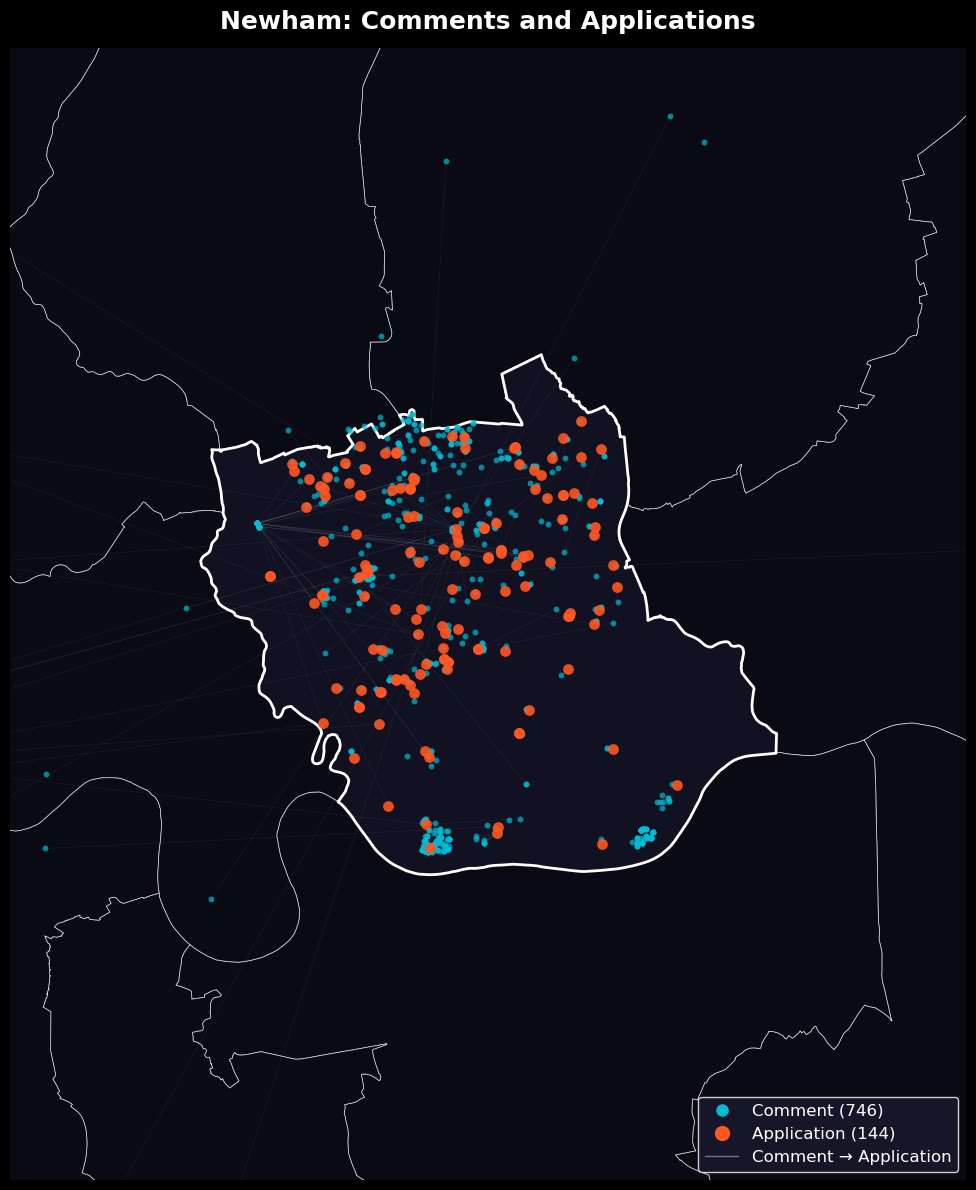

In [13]:
def _base_map(ax, title):
    """Draw London borough outlines + highlighted borough boundary."""
    ax.set_facecolor(STYLE["bg"])
    lad.to_crs("EPSG:4326").plot(
        ax=ax, color=STYLE["borough_fill"], edgecolor=STYLE["borough_edge"],
        linewidth=0.5, alpha=0.8,
    )
    borough_boundary.to_crs("EPSG:4326").plot(
        ax=ax, color=STYLE["highlight_fill"], edgecolor=STYLE["borough_edge"], linewidth=2.0,
    )
    ax.set_xlim(*MAP_XLIM)
    ax.set_ylim(*MAP_YLIM)
    ax.set_axis_off()
    ax.set_title(title, color=STYLE["text_color"], fontsize=18, fontweight="bold", pad=14)

has_coords = borough_c.dropna(subset=["lat", "lon"])

fig, ax = plt.subplots(figsize=(12, 12), facecolor=STYLE["bg"])
_base_map(ax, f"{BOROUGH}: Comments and Applications")

for _, row in linked.iterrows():
    ax.plot(
        [row["lon"], row["centroid_lon"]],
        [row["lat"], row["centroid_lat"]],
        color=STYLE["borough_edge"], alpha=0.08, linewidth=0.4, zorder=1,
    )

ax.scatter(
    has_coords["lon"], has_coords["lat"],
    color="#00bcd4", s=18, alpha=0.7, zorder=3, linewidths=0,
)
ax.scatter(
    app_centroids_commented["centroid_lon"], app_centroids_commented["centroid_lat"],
    color="#ff5722", s=60, alpha=0.9, zorder=4, linewidths=0,
)

legend_handles = [
    mlines.Line2D([], [], color="#00bcd4", marker="o", linestyle="None",
                  markersize=8, label=f"Comment ({len(has_coords)})"),
    mlines.Line2D([], [], color="#ff5722", marker="o", linestyle="None",
                  markersize=10, label=f"Application ({len(app_centroids_commented)})"),
    mlines.Line2D([], [], color=STYLE["borough_edge"], alpha=0.4, linewidth=1,
                  label="Comment → Application"),
]
ax.legend(handles=legend_handles, loc="lower right",
          facecolor=STYLE["leg_bg"], edgecolor=STYLE["leg_edge"],
          labelcolor=STYLE["text_color"], fontsize=12)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{_slug}_comment_application_graph.png",
            dpi=150, bbox_inches="tight", facecolor=STYLE["bg"])
plt.show()

## Map 2 — Comments coloured by topic

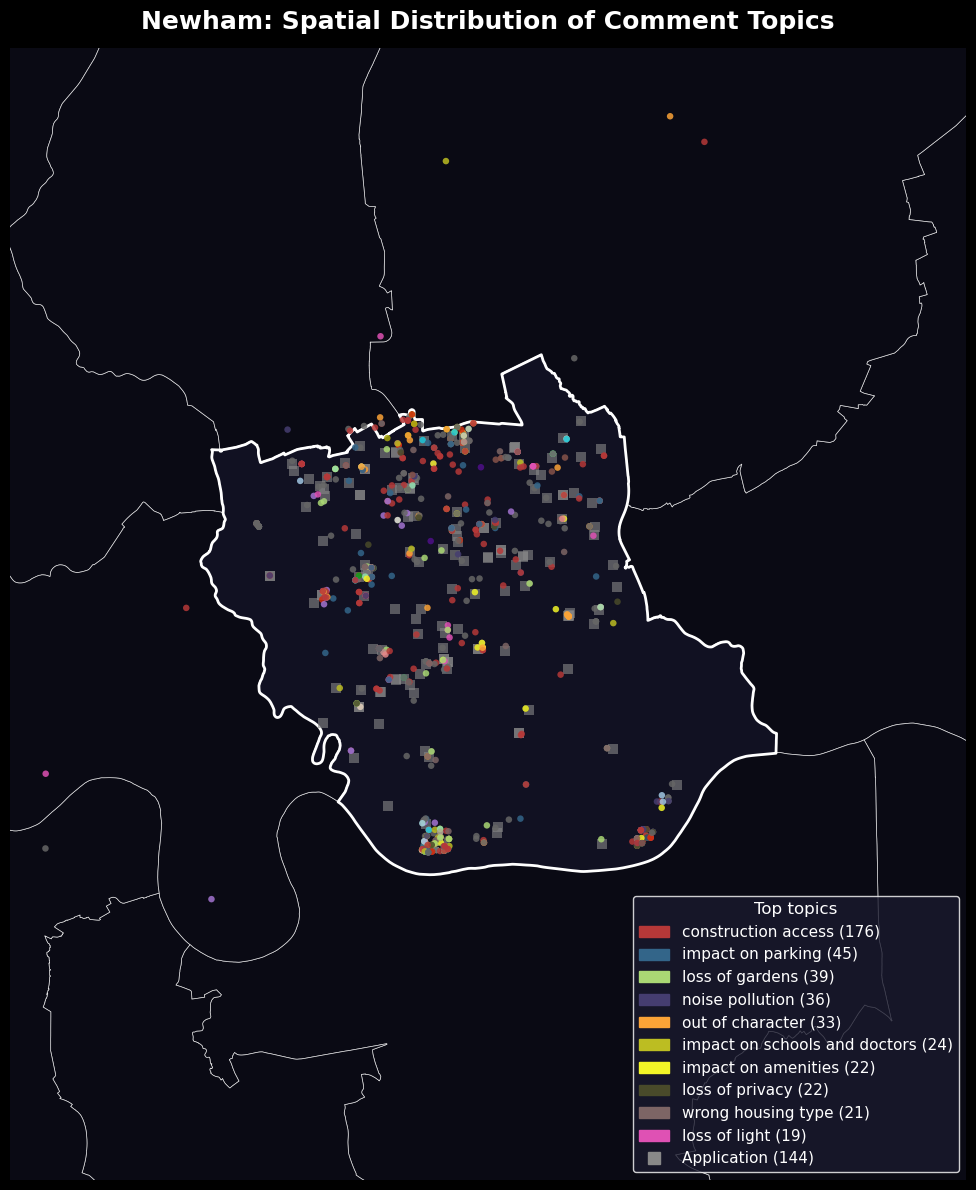

In [14]:
fig, ax = plt.subplots(figsize=(12, 12), facecolor=STYLE["bg"])
_base_map(ax, f"{BOROUGH}: Spatial Distribution of Comment Topics")

ax.scatter(
    app_centroids_commented["centroid_lon"], app_centroids_commented["centroid_lat"],
    color="#888888", s=50, alpha=0.6, zorder=2, linewidths=0, marker="s",
)

has_coords = borough_c.dropna(subset=["lat", "lon"])
ax.scatter(
    has_coords["lon"], has_coords["lat"],
    c=has_coords["topic_color"], s=22, alpha=0.85, zorder=3, linewidths=0,
)

topic_counts = (
    has_coords.dropna(subset=["primary_topic"])
    .groupby(["primary_topic", "topic_label", "topic_color"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .head(10)
)
legend_handles = [
    mpatches.Patch(color=row["topic_color"], label=f"{row['topic_label']} ({row['n']})")
    for _, row in topic_counts.iterrows()
]
legend_handles.append(
    mlines.Line2D([], [], color="#888888", marker="s", linestyle="None",
                  markersize=8, label=f"Application ({len(app_centroids_commented)})")
)
leg = ax.legend(handles=legend_handles, loc="lower right",
                facecolor=STYLE["leg_bg"], edgecolor=STYLE["leg_edge"],
                labelcolor=STYLE["text_color"], fontsize=11,
                title="Top topics", title_fontsize=12)
leg.get_title().set_color(STYLE["text_color"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{_slug}_comment_topics_map.png",
            dpi=150, bbox_inches="tight", facecolor=STYLE["bg"])
plt.show()

## Map 3 — Highlighted topic comments

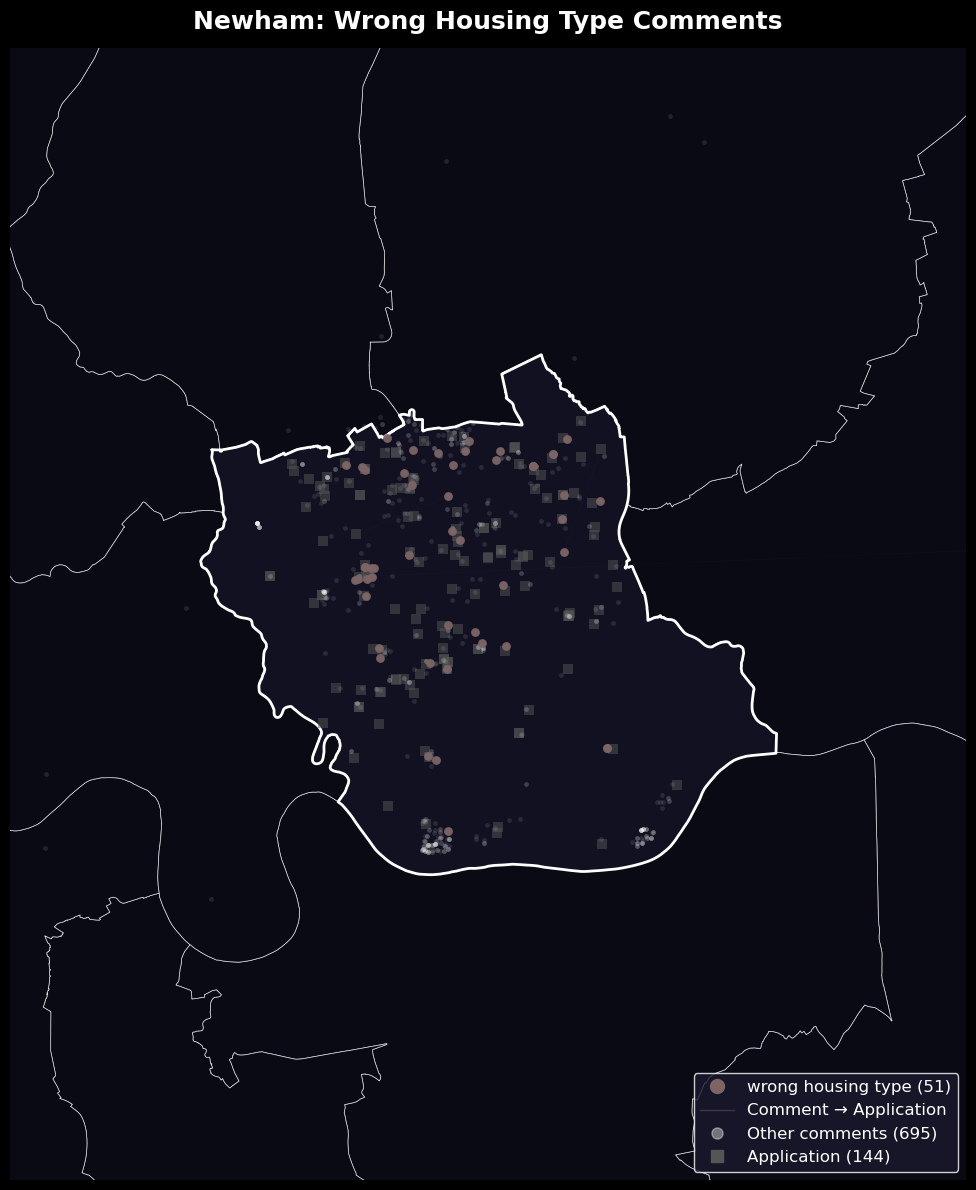

In [15]:
has_coords   = borough_c.dropna(subset=["lat", "lon"])
highlighted  = has_coords[has_coords["is_highlight"]]
not_highlighted = has_coords[~has_coords["is_highlight"]]
highlighted_linked = highlighted.dropna(subset=["centroid_lat", "centroid_lon"])

fig, ax = plt.subplots(figsize=(12, 12), facecolor=STYLE["bg"])
_base_map(ax, f"{BOROUGH}: {TOPIC_LABEL.title()} Comments")

ax.scatter(
    app_centroids_commented["centroid_lon"], app_centroids_commented["centroid_lat"],
    color="#555555", s=50, alpha=0.5, zorder=2, linewidths=0, marker="s",
)
ax.scatter(
    not_highlighted["lon"], not_highlighted["lat"],
    color=STYLE["ghost_color"], s=12, alpha=STYLE["ghost_alpha"], zorder=3, linewidths=0,
)

for _, row in highlighted_linked.iterrows():
    ax.plot(
        [row["lon"], row["centroid_lon"]],
        [row["lat"], row["centroid_lat"]],
        color=_highlight, alpha=0.08, linewidth=0.4, zorder=3,
    )

ax.scatter(
    highlighted["lon"], highlighted["lat"],
    color=_highlight, s=40, alpha=0.95, zorder=4, linewidths=0,
)

legend_handles = [
    mlines.Line2D([], [], color=_highlight, marker="o", linestyle="None",
                  markersize=10, label=f"{TOPIC_LABEL} ({len(highlighted)})"),
    mlines.Line2D([], [], color=_highlight, alpha=0.4, linewidth=1,
                  label="Comment → Application"),
    mlines.Line2D([], [], color=STYLE["ghost_color"], marker="o", linestyle="None",
                  markersize=8, alpha=0.4, label=f"Other comments ({len(not_highlighted)})"),
    mlines.Line2D([], [], color="#555555", marker="s", linestyle="None",
                  markersize=8, label=f"Application ({len(app_centroids_commented)})"),
]
ax.legend(handles=legend_handles, loc="lower right",
          facecolor=STYLE["leg_bg"], edgecolor=STYLE["leg_edge"],
          labelcolor=STYLE["text_color"], fontsize=12)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{_slug}_{TOPIC_ID}_highlight_map.png",
            dpi=150, bbox_inches="tight", facecolor=STYLE["bg"])
plt.show()

## Map 4 — Applications with highlighted topic comments

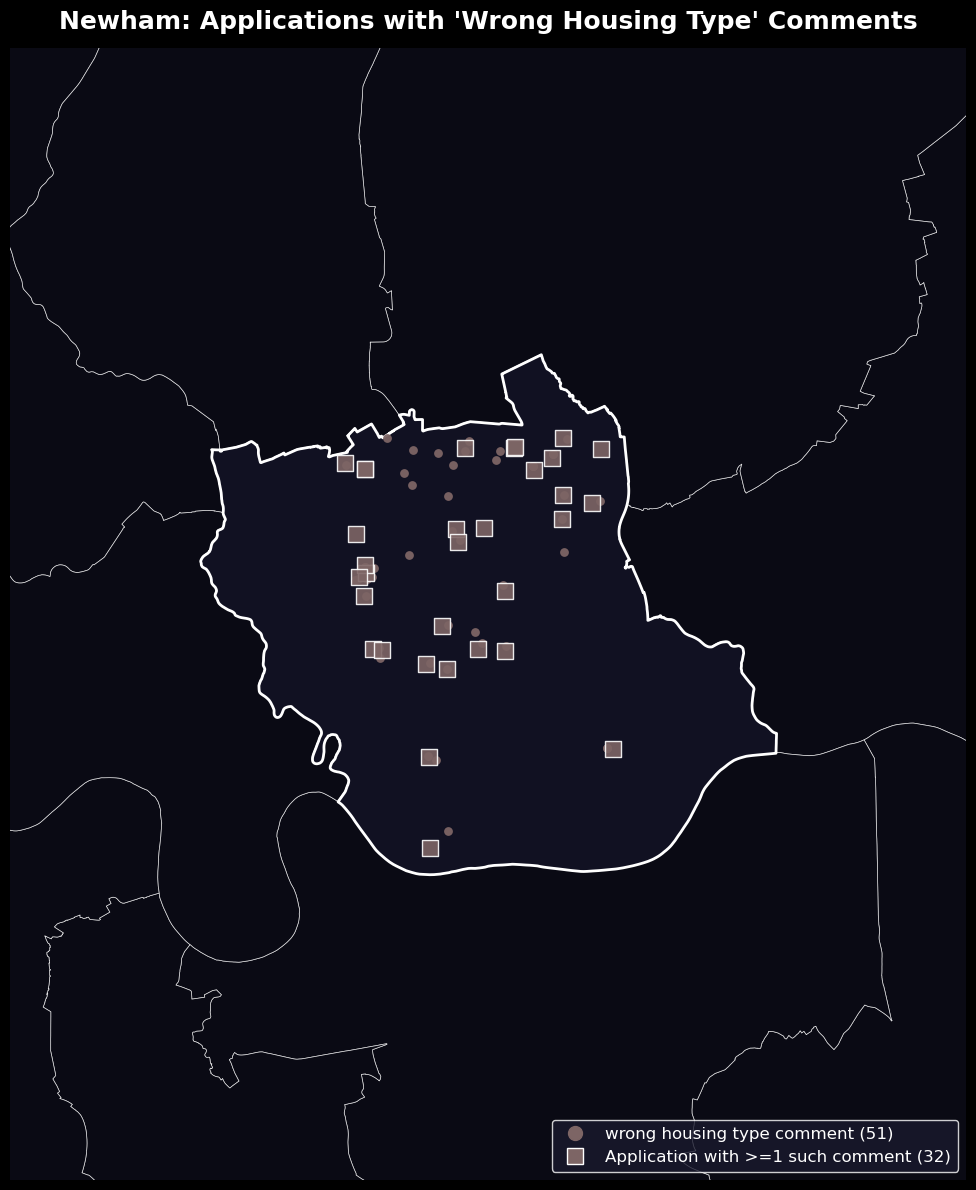

In [16]:
highlighted = borough_c[borough_c["is_highlight"]].dropna(subset=["lat", "lon"])

fig, ax = plt.subplots(figsize=(12, 12), facecolor=STYLE["bg"])
_base_map(ax, f"{BOROUGH}: Applications with '{TOPIC_LABEL.title()}' Comments")

ax.scatter(
    highlighted["lon"], highlighted["lat"],
    color=_highlight, s=40, alpha=0.95, zorder=3, linewidths=0,
)
ax.scatter(
    app_centroids_highlight["centroid_lon"], app_centroids_highlight["centroid_lat"],
    color=_highlight, s=120, alpha=0.9, zorder=4, linewidths=1,
    edgecolors=STYLE["borough_edge"], marker="s",
)

legend_handles = [
    mlines.Line2D([], [], color=_highlight, marker="o", linestyle="None",
                  markersize=10, label=f"{TOPIC_LABEL} comment ({len(highlighted)})"),
    mlines.Line2D([], [], color=_highlight, marker="s", linestyle="None",
                  markersize=12, markeredgecolor=STYLE["borough_edge"], markeredgewidth=1,
                  label=f"Application with >=1 such comment ({len(app_centroids_highlight)})"),
]
ax.legend(handles=legend_handles, loc="lower right",
          facecolor=STYLE["leg_bg"], edgecolor=STYLE["leg_edge"],
          labelcolor=STYLE["text_color"], fontsize=12)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{_slug}_{TOPIC_ID}_applications_map.png",
            dpi=150, bbox_inches="tight", facecolor=STYLE["bg"])
plt.show()